In [1]:
%load_ext autoreload
%autoreload 2

# ignore warnings for readability
import warnings
warnings.filterwarnings('ignore')

import os
from os.path import join
from collections import defaultdict
import numpy as np
import pandas as pd
import tqdm
from sklearn.linear_model import LinearRegression

import logging
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('euclid_stylesheet_v2.mplstyle')
mpl.rcParams['figure.dpi'] = 300

In [2]:
mdir = './saved_models'


def r2logm(r):
    # see preprocessing.ipynb for this measurement
    coef = 0.36752
    intercept = -5.30640
    return (np.log10(r)-intercept)/coef

In [3]:
datanames = ['wC50', 'wC100', 'dC50', 'dC100']
runnames = ['base', 'gals_nle', 'summ_nle', 'gnn_npe']
modelnames = ['msig', 'pamico', 'mamp', 'gals_nle', 'summ_nle', 'gnn_npe']
Nfolds = 10
folds = np.arange(Nfolds)

datatitles = dict(
    wC50='Wide $50\%$',
    wC100='Wide $100\%$',
    dC50='Deep $50\%$',
    dC100='Deep $100\%$'
)
modeltitles = dict(
    msig='$M$--$\sigma$',
    pamico=r'$M$--$\lambda_{\rm spec}$',
    mamp='MAMPOSSt',
    gals_nle='Galaxy-Net',
    summ_nle='Summary-Net',
    gnn_npe='Graph-Net',
    true='True',
    prior='Prior',
    dummy='Dummy'
)

In [4]:
from scipy.stats import skewnorm
from scipy.optimize import minimize


def fit_skewed_normal(p16, p50, p84):
    target_percentiles = [0.16, 0.50, 0.84]
    observed_values = [p16, p50, p84]

    def objective(params):
        loc, scale, alpha = params
        if scale <= 0:
            return np.inf
        skewed_gaussian = skewnorm(alpha, loc=loc, scale=scale)
        calculated_values = skewed_gaussian.ppf(target_percentiles)
        return np.sum((calculated_values - observed_values) ** 2)

    initial_guess = [p50, (p84 - p16) / 2, 0.5]
    result = minimize(objective, initial_guess)
    loc, scale, alpha = result.x
    return skewnorm(alpha, loc=loc, scale=scale)

In [5]:
# load train/test
header = 'APR24'
datadir = './data/processed'

theta, fold, ids, richs, zclus, Ngal = {}, {}, {}, {}, {}, {}
for d in datanames:
    dirpath = join(datadir, f'{header}{d}')
    print('Loading:', dirpath)
    theta[d] = np.load(join(dirpath, 'theta_batch.npy'))
    fold[d] = np.load(join(dirpath, 'folds_batch.npy'))
    ids[d] = np.load(join(dirpath, 'ids_batch.npy'))
    metas = np.load(join(dirpath, 'metas_batch.npy'))
    zclus[d] = metas[:, 3]  # cluster photometric redshift
    richs[d] = metas[:, 1]  # sum of AMICO photometry
    Ngal[d] = np.load(join(dirpath, 'x_sum.npy'))[:, -1]

Ndata = {d: len(theta[d]) for d in datanames}
print(Ndata)

Loading: ./data/processed/APR24wC50
Loading: ./data/processed/APR24wC100
Loading: ./data/processed/APR24dC50
Loading: ./data/processed/APR24dC100
{'wC50': 840, 'wC100': 907, 'dC50': 1998, 'dC100': 2014}


In [6]:
Nsamp = 100
preds = defaultdict(dict)
for d in datanames:
    for r in runnames:
        # setup
        if r == 'base':
            preds[d]['msig'] = np.ones((Ndata[d], 2))*np.nan
            preds[d]['pamico'] = np.ones((Ndata[d], 2))*np.nan
        else:
            preds[d][r] = np.full((Ndata[d], Nsamp, 1), np.nan)

        # load
        for f in folds:
            if r == 'gnn_npe':
                dirname = f'oct02_{r}_{d}_f{f}'
            else:
                dirname = f'apr24_{r}_{d}_f{f}'
            if r == 'base':
                # Msig
                samplefile = join(mdir, dirname, 'msig.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['msig'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['msig'][:, 1], place_ids, s['std'])

                # Pamico
                samplefile = join(mdir, dirname, 'Pamico.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['pamico'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['pamico'][:, 1], place_ids, s['std'])

            else:
                # ML models
                samplefile = join(mdir, dirname, 'posterior_samples.npy')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                s = np.swapaxes(s, 0, 1)
                s = s[:, :Nsamp]  # subsample if necessary
                preds[d][r][fold[d] == f] = s

In [7]:
# load mamposst

mamnames = {
    'wC50': 'wide50', 'wC100': 'wide100', 'dC50': 'deep50', 'dC100': 'deep100'
}
modeldir = './saved_models/mamposst_newprior_dec1824/'

for k, v in mamnames.items():
    isamp = pd.read_csv(join(modeldir, f'result_MockFS_NewAMICO_{v}.dat'),
                        delimiter=' ', skipinitialspace=True)
    isamp['id'] = isamp['#ClusterID'].astype(int)
    # convert r200 to logm
    for c in isamp.columns:
        if 'r200' not in c:
            continue
        isamp['logm'+c[4:]] = r2logm(isamp[c])

    # put in preds
    preds[k]['mamp'] = np.ones((Ndata[k], 5))*np.nan
    place_ids = np.searchsorted(ids[k], isamp['id'].values)
    mask = place_ids < Ndata[k]
    _s = isamp[['logmlow(68)', 'logmup(68)', 'logmlow(95)',
                'logmup(95)', 'logmMAM']].values
    preds[k]['mamp'][place_ids[mask]] = _s[mask]

In [8]:
# calculate percentiles from predictions
q = 100*np.array([0.16, 0.84, 0.5, 0.025, 0.975])
percs = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        if m == 'msig' or m == 'pamico':
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0]-t_[:, 1], t_[:, 0]+t_[:, 1], t_[:, 0],
                    t_[:, 0]-2*t_[:, 1], t_[:, 0]+2*t_[:, 1]],
                axis=1).T
        elif m == 'mamp':
            if m not in preds[d]:
                continue
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0], t_[:, 1], t_[:, 4], t_[:, 2], t_[:, 3]],
                axis=1).T
        else:
            t_ = preds[d][m]
            percs[d][m] = np.percentile(t_, q, axis=1)[..., 0]
# percs is of shape (5, Ndata)
# dim 0 is of order [16, 84, 50, 2.5, 97.5]

In [9]:
# Compute quality control
def quality_control(percs):
    # checks if we have a reasonable median prediction
    # checks if we're not missing a prediction (not nan)
    med = percs[2]
    mask = (med > 12) & (med < 16)

    err = (percs[1] - percs[0])/2
    mask &= err < 1
    return mask


qc = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        qc[d][m] = quality_control(percs[d][m])

In [10]:
# Remove Ngal < 3
for d in datanames:
    mask = Ngal[d] >= 3

    theta[d] = theta[d][mask]
    fold[d] = fold[d][mask]
    ids[d] = ids[d][mask]
    richs[d] = richs[d][mask]
    zclus[d] = zclus[d][mask]
    Ngal[d] = Ngal[d][mask]
    Ndata[d] = len(theta[d])

    for m in modelnames:
        if m not in percs[d]:
            continue
        preds[d][m] = preds[d][m][mask]
        percs[d][m] = percs[d][m][:, mask]
        qc[d][m] = qc[d][m][mask]

## MCMC

Forward parametrization of the mass-richness relation (see `8_newappendix.tex`).
We model $p(\log_{10}\lambda\,|\,m, z, \theta)$ and assume $\phi(m|z) = p(m)$,
so the prior ratio cancels and the operand reduces to the richness residual.

**v4 adds a redshift-dependent richness selection.** The sample is truncated at a
cut $\lambda_{\rm cut}(z)$ that rises with redshift, so we divide the relation by
the surviving fraction above the cut (see `8_newappendix.tex` final paragraph).
The cut is parametrized as
$\log_{10}\lambda_{\rm cut}(z) = c_0 + c_1\log_{10}\frac{1+z}{1+z_0}$ and is
**fit in advance from the lower envelope of the data, then held fixed during
MCMC** (it is passed to `run_mcmc` as the constants `c0, c1`, not sampled). To
use a survey-supplied threshold instead, just overwrite `c0_fit, c1_fit`.

Sampled parameters: $\theta = \{\pi_0, F_m, G_z, \sigma_\lambda\}$;
fixed: $\{c_0, c_1\}$.

In [11]:
# LinearRegression to estimate the FORWARD relation: log10(lambda) | m, z
# (new appendix parametrization, see 8_newappendix.tex)
d = 'dC100'
rs = richs[d]
zs = zclus[d]
mtrue = theta[d][:, 0]

# find pivots: mass pivot m0 and redshift pivot z0
m0_piv, z0 = 14.0, 1.0

# regress log10(lambda) on (m - m0) and log10((1+z)/(1+z0))
dm = mtrue - m0_piv
dz = np.log10((1+zs)/(1+z0))
X = np.stack([dm, dz], axis=1)
ylam = np.log10(rs)
reg = LinearRegression().fit(X, ylam)
y_pred = reg.predict(X)
residual_std = np.std(ylam - y_pred)
print(f'pi0 (intercept): {reg.intercept_:.3f}')
print(f'F_m  (mass slope): {reg.coef_[0]:.3f}')
print(f'G_z  (redshift slope): {reg.coef_[1]:.3f}')
print(f'sigma_lambda (residual std): {residual_std:.3f}')

pi0 (intercept): 1.409
F_m  (mass slope): 0.334
G_z  (redshift slope): 2.075
sigma_lambda (residual std): 0.134


In [12]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp, log_ndtr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import corner

# Forward (new appendix) parametrization WITH a redshift-dependent richness
# selection cut, see 8_newappendix.tex.
#
# Mean of the relation (Gaussian in log10 lambda):
#   <log10 lambda | m, z> = pi0 + Fm*(m - m0) + Gz*log10((1+z)/(1+z0))
#
# Selection: the sample only contains clusters with lambda > lambda_cut(z),
# where the cut rises with redshift. The cut is
#   log10 lambda_cut(z) = c0 + c1*log10((1+z)/(1+z0)),
# with c0, c1 FIT IN ADVANCE and held FIXED during MCMC (passed as constants).
# We renormalize the relation by the surviving fraction above the cut:
#   T_i(m) = P(log10 lambda > log10 lambda_cut(z_i) | mean, sigl)
#          = Phi( (<log10 lambda|m,z_i> - log10 lambda_cut(z_i)) / sigl ).
# The operand gains a term  - log T_i(m)  (log_ndtr is the log-normal-CDF,
# numerically stable in the deep-tail regime).
#
# Sampled theta = {pi0, Fm, Gz, sigl}; fixed = {c0, c1, m0, z0}.
#
# SPEEDUPS (exact, same posterior):
#   1. precompute the constants dm = samps - m0, dz = log10((1+z)/(1+z0)),
#      and logcut = c0 + c1*dz ONCE in run_mcmc, so NUTS stops recomputing
#      log10(...) every leapfrog step (see model / _loglike_pre below);
#   2. dense_mass=True so the F_m-sigma_lambda / pi0-G_z correlations are
#      captured by the metric (far fewer leapfrog steps);
#   3. chain_method='vectorized' so the chains run as one vmap'd program.


# ---- diagnostic / plotting forms (full, readable signatures) ----
def lamb_mean(m, zs, m0, z0, pi0, Fm, Gz):
    # mean of log10(lambda) given mass m and redshift z
    return pi0 + Fm*(m - m0) + Gz*(jnp.log10((1+zs)/(1+z0)))


def log_lambda_cut(zs, z0, c0, c1):
    # redshift-dependent richness selection threshold, in log10(lambda)
    return c0 + c1*(jnp.log10((1+zs)/(1+z0)))


def operand(samps, loglambs, zs, m0, z0, sigl, pi0, Fm, Gz, c0, c1):
    # Gamma_i(m, theta) with phi(m|z) = p(m) and a fixed selection cut; samps is
    # (Nclu, Nsamp). loglambs, zs are (Nclu,) observed log10(richness), redshift.
    lam_est = lamb_mean(samps, zs[:, None], m0, z0, pi0, Fm, Gz)
    resid = -(loglambs[:, None] - lam_est)**2/(2*(sigl**2))
    logcut = log_lambda_cut(zs[:, None], z0, c0, c1)
    log_surv = log_ndtr((lam_est - logcut)/sigl)
    return resid - log_surv


def log_likelihood(samps, loglambs, zs, m0, z0, sigl, pi0, Fm, Gz, c0, c1):
    Nclu, Nsamp = samps.shape
    to_sum = operand(samps, loglambs, zs, m0, z0, sigl, pi0, Fm, Gz, c0, c1)
    summed = logsumexp(to_sum, axis=1)
    return -Nclu*jnp.log(sigl) - Nclu*jnp.log(Nsamp) + jnp.sum(summed)


# ---- precomputed-constant form used inside MCMC (speedup 1) ----
def _loglike_pre(dm, dz, loglambs, logcut, sigl, pi0, Fm, Gz):
    # dm = samps - m0, shape (Nclu, Nsamp); dz, loglambs, logcut are (Nclu, 1).
    # Identical likelihood to log_likelihood(), with the constant log10/offset
    # terms hoisted out of the per-step evaluation.
    lam_est = pi0 + Fm*dm + Gz*dz                       # (Nclu, Nsamp)
    resid = -(loglambs - lam_est)**2/(2*(sigl**2))
    log_surv = log_ndtr((lam_est - logcut)/sigl)
    summed = logsumexp(resid - log_surv, axis=1)        # (Nclu,)
    Nclu, Nsamp = dm.shape
    return -Nclu*jnp.log(sigl) - Nclu*jnp.log(Nsamp) + jnp.sum(summed)


def model(dm, dz, loglambs, logcut):
    pi0 = numpyro.sample("pi0", dist.Uniform(-2, 5))
    Fm = numpyro.sample("Fm", dist.Uniform(-10, 10))
    Gz = numpyro.sample("Gz", dist.Uniform(-10, 10))
    sigl = numpyro.sample("sigl", dist.LogUniform(1e-2, 2.0))
    numpyro.factor(
        "log_likelihood",
        _loglike_pre(dm, dz, loglambs, logcut, sigl, pi0, Fm, Gz))


def run_mcmc(samps, loglambs, zs, m0, z0, c0, c1,
             warmup=500, samples=1000, chains=4):
    # precompute the fixed pieces ONCE (speedup 1)
    dz_ = np.log10((1+np.asarray(zs))/(1+z0))
    dm = jnp.asarray(np.asarray(samps) - m0)            # (Nclu, Nsamp)
    dz = jnp.asarray(dz_)[:, None]                      # (Nclu, 1)
    logcut = jnp.asarray(c0 + c1*dz_)[:, None]          # (Nclu, 1)
    loglambs = jnp.asarray(np.asarray(loglambs))[:, None]

    # dense mass matrix (speedup 2) + vectorized chains (speedup 3)
    kernel = NUTS(model, dense_mass=True)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples,
                num_chains=chains, chain_method='vectorized')
    mcmc.run(jax.random.PRNGKey(0),
             dm=dm, dz=dz, loglambs=loglambs, logcut=logcut)
    return mcmc.get_samples()

In [13]:
# ============================================================
# Likelihood playground -- set the knobs here
# ============================================================
d = 'dC100'        # dataset: wC50, wC100, dC50, dC100
m = 'prior'        # mass model: msig, pamico, mamp, gals_nle, summ_nle,
#             gnn_npe, true, dummy
m0_piv, z0 = 13.78, 0.82     # mass and redshift pivots
m0, sig0 = 13.78, 0.348      # assumed mass prior p(m) ~ N(m0, sig0^2)
# ============================================================

rs = richs[d]
zs = zclus[d]
ytrue = theta[d][:, 0]

# build mass posterior samples `samps` of shape (Nclu, Nsamp)
if m in ['msig', 'pamico']:
    mu, sig = preds[d][m].T
    samps = mu[:, None] + sig[:, None]*np.random.randn(len(mu), Nsamp)
elif m == 'mamp':
    ps = preds[d][m]
    p16, p84, p50 = ps[:, 0], ps[:, 1], ps[:, 4]
    samps = np.array([
        fit_skewed_normal(p16[i], p50[i], p84[i]).rvs(Nsamp)
        if not np.isnan(p16[i]) else np.full(Nsamp, np.nan)
        for i in tqdm.tqdm(range(len(p16)))
    ])
elif m == 'dummy':
    # synthetic posteriors for testing the likelihood: noisy + prior-shrunk
    mu_p, sig_p = 13.78, 0.35   # mock inference prior p(m)
    sigma_n = 0.3               # injected noise (dex)
    post_var = 1.0/(1.0/sigma_n**2 + 1.0/sig_p**2)
    x = ytrue + sigma_n*np.random.randn(len(ytrue))
    post_mean = post_var*(x/sigma_n**2 + mu_p/sig_p**2)
    samps = (post_mean[:, None]
             + np.sqrt(post_var)*np.random.randn(len(ytrue), Nsamp))
    qc[d]['dummy'] = qc[d]['gnn_npe']
elif m == 'prior':
    samps = np.random.randn(len(ytrue), 1) * sig0 + m0
    qc[d]['prior'] = qc[d]['gnn_npe']
elif m == 'true':
    samps = ytrue[:, None]
    qc[d]['true'] = qc[d]['gnn_npe']
else:
    samps = preds[d][m][..., 0]

# quality control + observed log10 richness (the "data" in the likelihood)
mask = qc[d][m]
rs, zs, samps, ytrue = rs[mask], zs[mask], samps[mask], ytrue[mask]
loglambs = np.log10(rs)

print('samps shape:', samps.shape)
print('true mass mean/std:', ytrue.mean(), ytrue.std())

samps shape: (2014, 1)
true mass mean/std: 13.776200370712232 0.3479471949306839


In [14]:
# # OPTIONAL: smooth + resample each cluster's mass posterior with a Gaussian KDE.
# # Operates on the existing `samps` from the cell above. Comment out the final
# # `samps = kde_resample(samps)` line (or skip this cell) to keep the raw samples.
# from scipy.stats import gaussian_kde


# def kde_resample(samps, n=None, bw=None, seed=0):
#     # fit a 1D Gaussian KDE per cluster and draw `n` new mass samples
#     rng = np.random.default_rng(seed)
#     n = samps.shape[1] if n is None else n
#     out = np.empty((samps.shape[0], n))
#     for i in range(samps.shape[0]):
#         si = samps[i][np.isfinite(samps[i])]
#         if si.size < 2 or np.ptp(si) == 0:
#             # too few / degenerate samples: pass through (or NaN if empty)
#             out[i] = np.full(n, np.nan if si.size == 0 else si[0])
#             continue
#         out[i] = gaussian_kde(si, bw_method=bw).resample(n, seed=rng).ravel()
#     return out


# samps = kde_resample(samps, 1000)
# print('KDE-resampled samps shape:', samps.shape)

c0_fit (cut at z0): 0.986
c1_fit (cut z-slope): 2.424


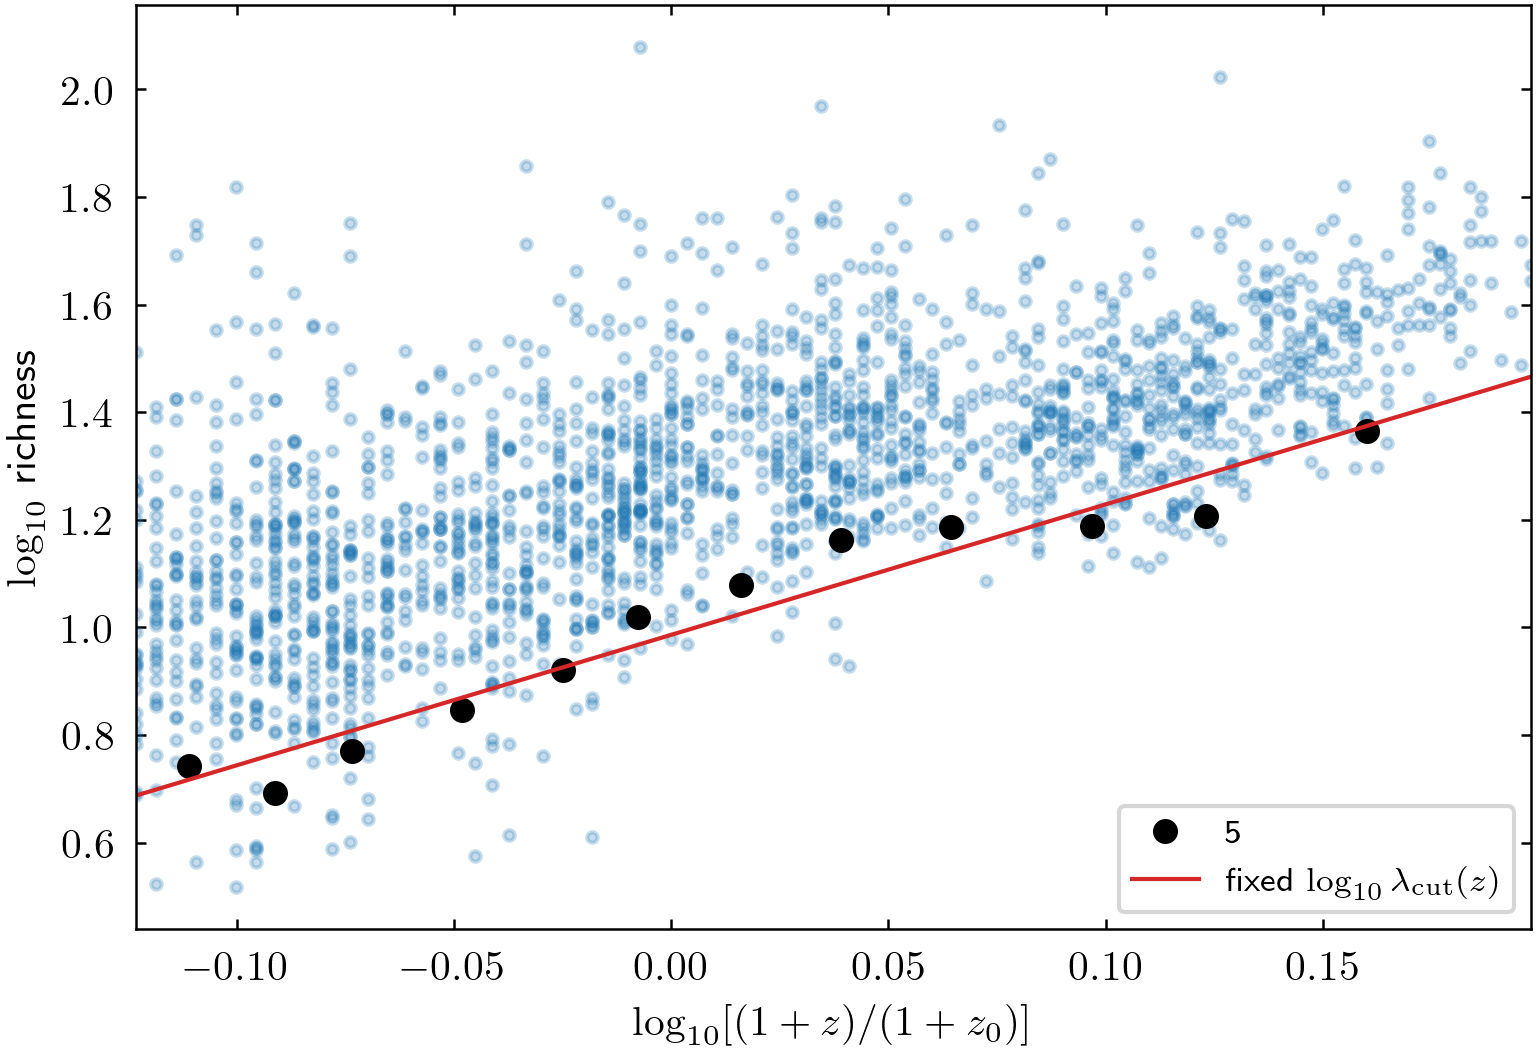

In [25]:
# ============================================================
# Fit the selection cut IN ADVANCE, then hold it fixed during MCMC.
#   log10 lambda_cut(z) = c0 + c1 * log10((1+z)/(1+z0))
# Estimated from the lower envelope of log10(lambda) vs redshift.
# (Replace c0_fit, c1_fit with survey-completeness values if available.)
# ============================================================
qlow = 0.05     # lower-envelope quantile defining the "cut"
nbins = 12      # redshift bins for the envelope

dz = np.log10((1+zs)/(1+z0))
edges = np.quantile(dz, np.linspace(0, 1, nbins+1))
cen, low = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    sel = (dz >= lo) & (dz <= hi)
    if sel.sum() < 5:
        continue
    cen.append(dz[sel].mean())
    low.append(np.quantile(loglambs[sel], qlow))
cen, low = np.array(cen), np.array(low)

c1_fit, c0_fit = np.polyfit(cen, low, 1)   # slope, intercept
print(f'c0_fit (cut at z0): {c0_fit:.3f}')
print(f'c1_fit (cut z-slope): {c1_fit:.3f}')

# quick check: envelope points + fitted line over the data
f, ax = plt.subplots(figsize=(6, 4))
ax.plot(dz, loglambs, '.', alpha=0.25, color='C0')
ax.plot(cen, low, 'o', color='k', label=f'{qlow:.0%} envelope')
xg = np.linspace(dz.min(), dz.max(), 50)
ax.plot(xg, c0_fit + c1_fit*xg, '-', color='C3',
        label=r'fixed $\log_{10}\lambda_{\rm cut}(z)$')
ax.set_xlabel(r'$\log_{10}[(1+z)/(1+z_0)]$')
ax.set_ylabel(r'$\log_{10}$ richness')
ax.legend(fontsize=8)

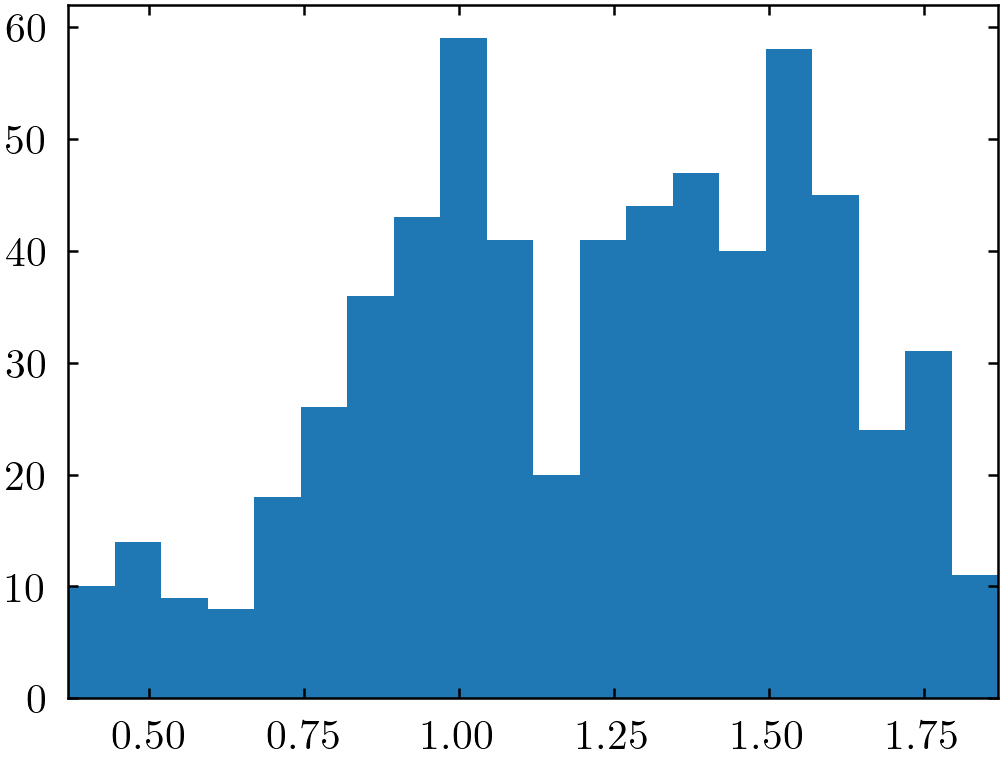

In [ ]:
m = loglambs > 1.4
plt.hist(zs[m], 20)

In [26]:
# Run MCMC (forward likelihood, fixed selection cut) with posterior masses
samples = run_mcmc(samps, loglambs, zs, m0_piv, z0, c0_fit, c1_fit,
                   samples=2000, chains=2)
print(samps.mean())

sample: 100%|██████████| 2500/2500 [00:04<00:00, 543.68it/s] 

13.785039624992882


In [27]:
# Run MCMC with true masses for reference (same fixed cut)
truesamples = run_mcmc(ytrue[:, None], loglambs, zs, m0_piv, z0,
                       c0_fit, c1_fit, samples=2000, chains=2)
print(ytrue.mean())

sample: 100%|██████████| 2500/2500 [00:05<00:00, 492.63it/s]


13.776200370712232


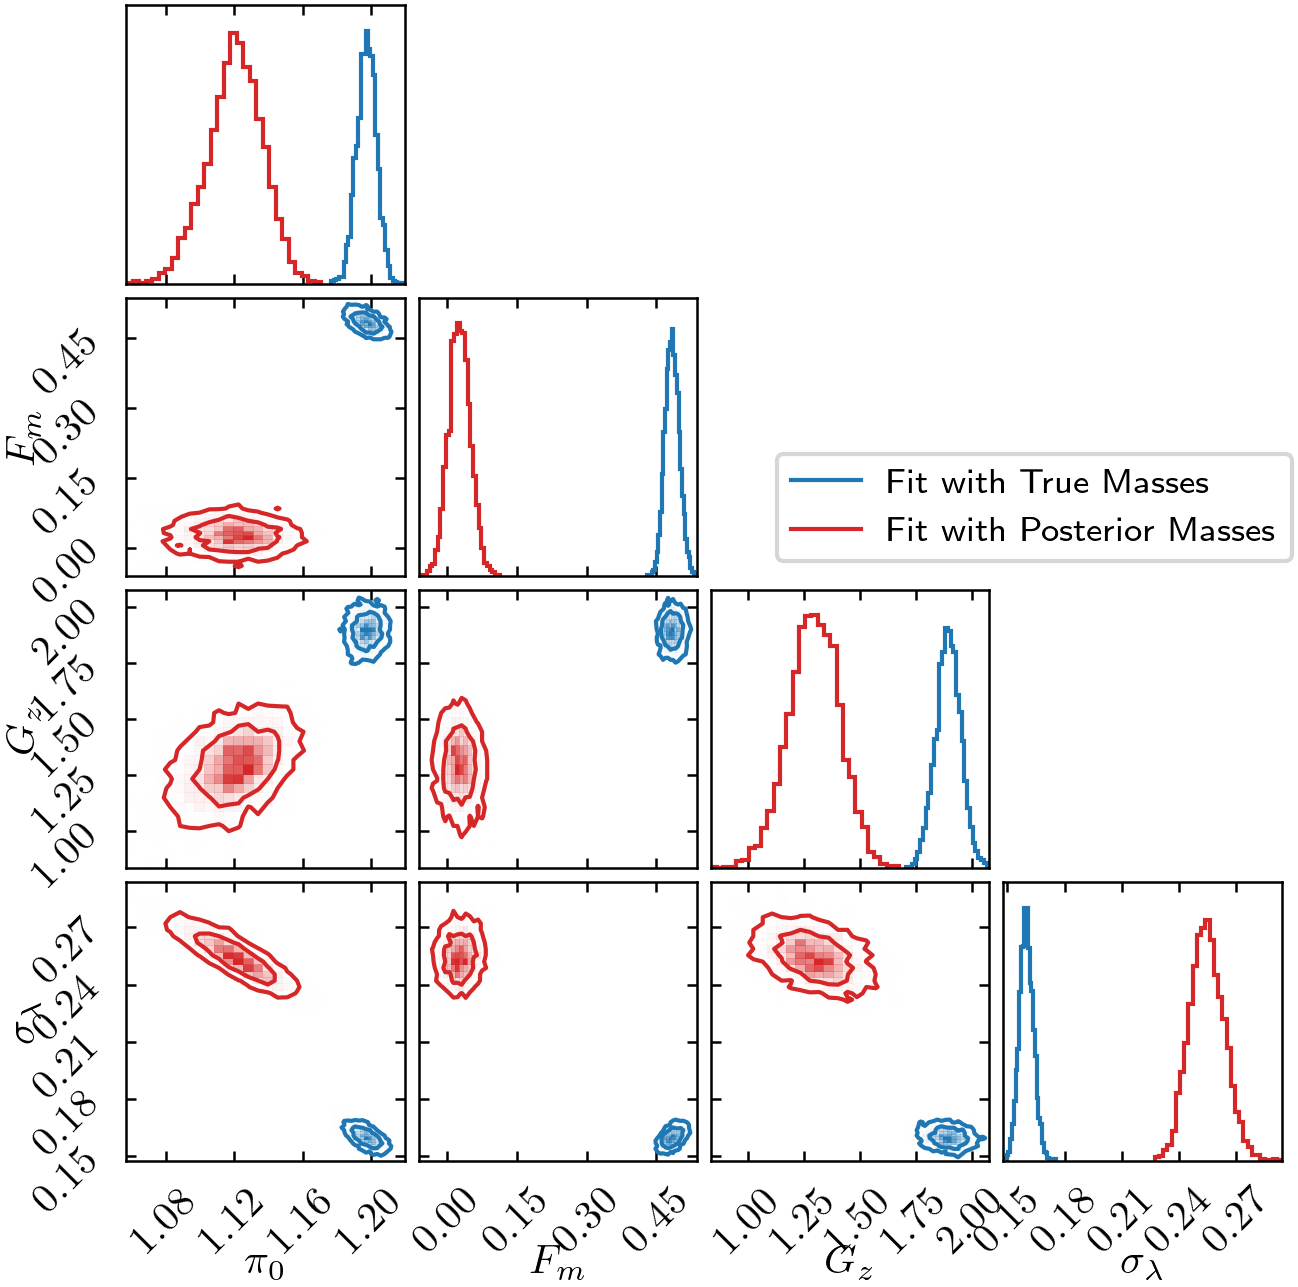

In [28]:
# plot the corner plot
fig = plt.figure(figsize=(4.5, 4.5))

# parameter ranges; set to a list of (lo, hi) per param to fix the axes
ranges = None

labels = [r"$\pi_0$", r"$F_m$", r"$G_z$", r"$\sigma_\lambda$"]
keys = ['pi0', 'Fm', 'Gz', 'sigl']

# Fit with Posterior Masses
data = np.vstack([samples[k] for k in keys]).T
corner.corner(
    data, labels=labels, levels=[0.68, 0.95], range=ranges, fig=fig,
    color='C3', alpha=0.1, plot_contours=True, hist_bin_factor=1.5,
    plot_datapoints=False, no_fill_contours=True)

# Fit with True Masses
data = np.vstack([truesamples[k] for k in keys]).T
corner.corner(
    data, labels=labels, levels=[0.68, 0.95], range=ranges, fig=fig,
    color='C0', plot_contours=True, hist_bin_factor=1.5,
    plot_datapoints=False, no_fill_contours=True)

plt.plot([], [], color='C0', label='Fit with True Masses')
plt.plot([], [], color='C3', label='Fit with Posterior Masses')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 2.6), fontsize='small')

# fig.savefig(f'figures/lambdam_corner_{d}.pdf', bbox_inches='tight')

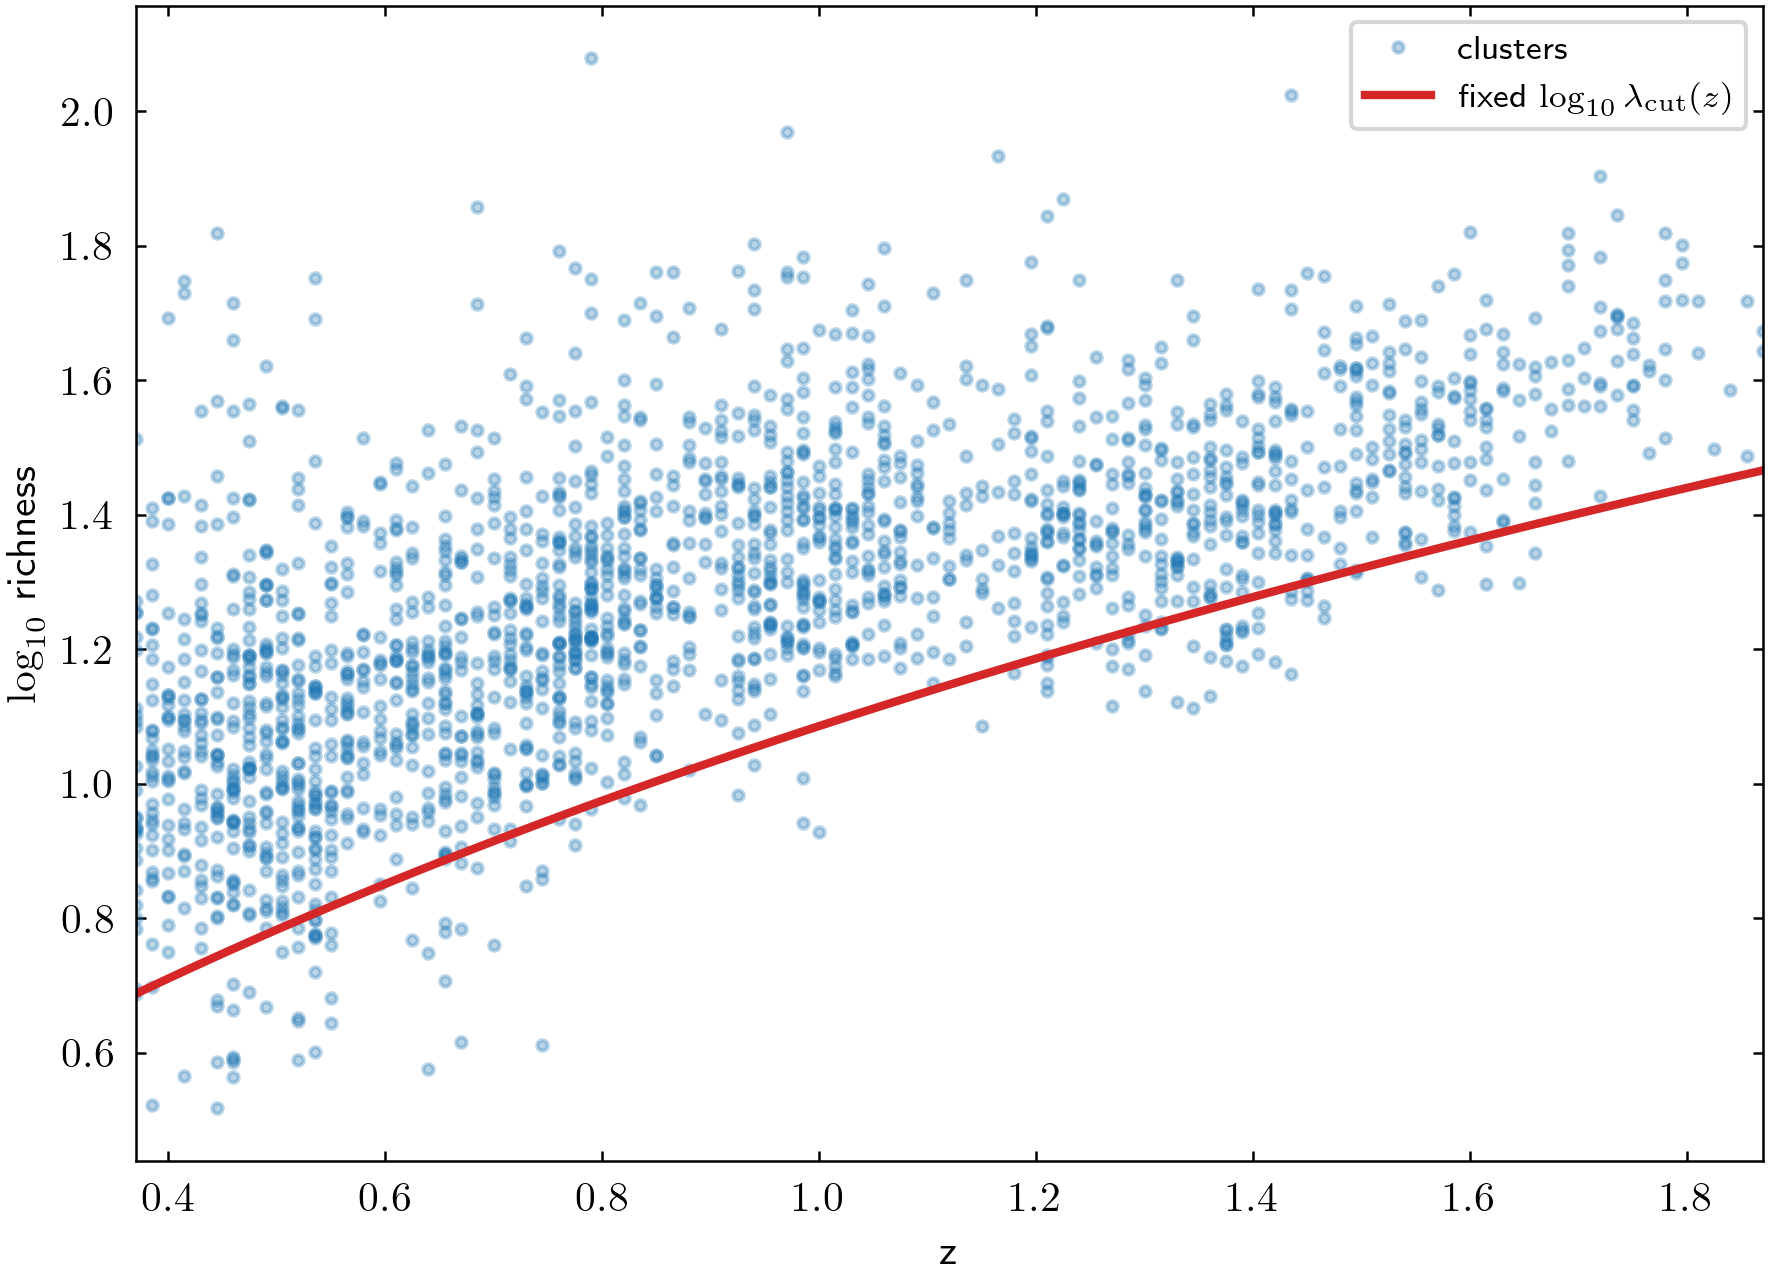

In [29]:
# Visualize the fixed selection cut lambda_cut(z) over the data
zg = np.linspace(zs.min(), zs.max(), 100)
dzg = np.log10((1+zg)/(1+z0))

f, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(zs, loglambs, '.', alpha=0.3, color='C0', label='clusters')
ax.plot(zg, c0_fit + c1_fit*dzg, '-', color='C3', lw=2,
        label=r'fixed $\log_{10}\lambda_{\rm cut}(z)$')
ax.set_xlabel('z')
ax.set_ylabel(r'$\log_{10}$ richness')
ax.legend(fontsize=8)

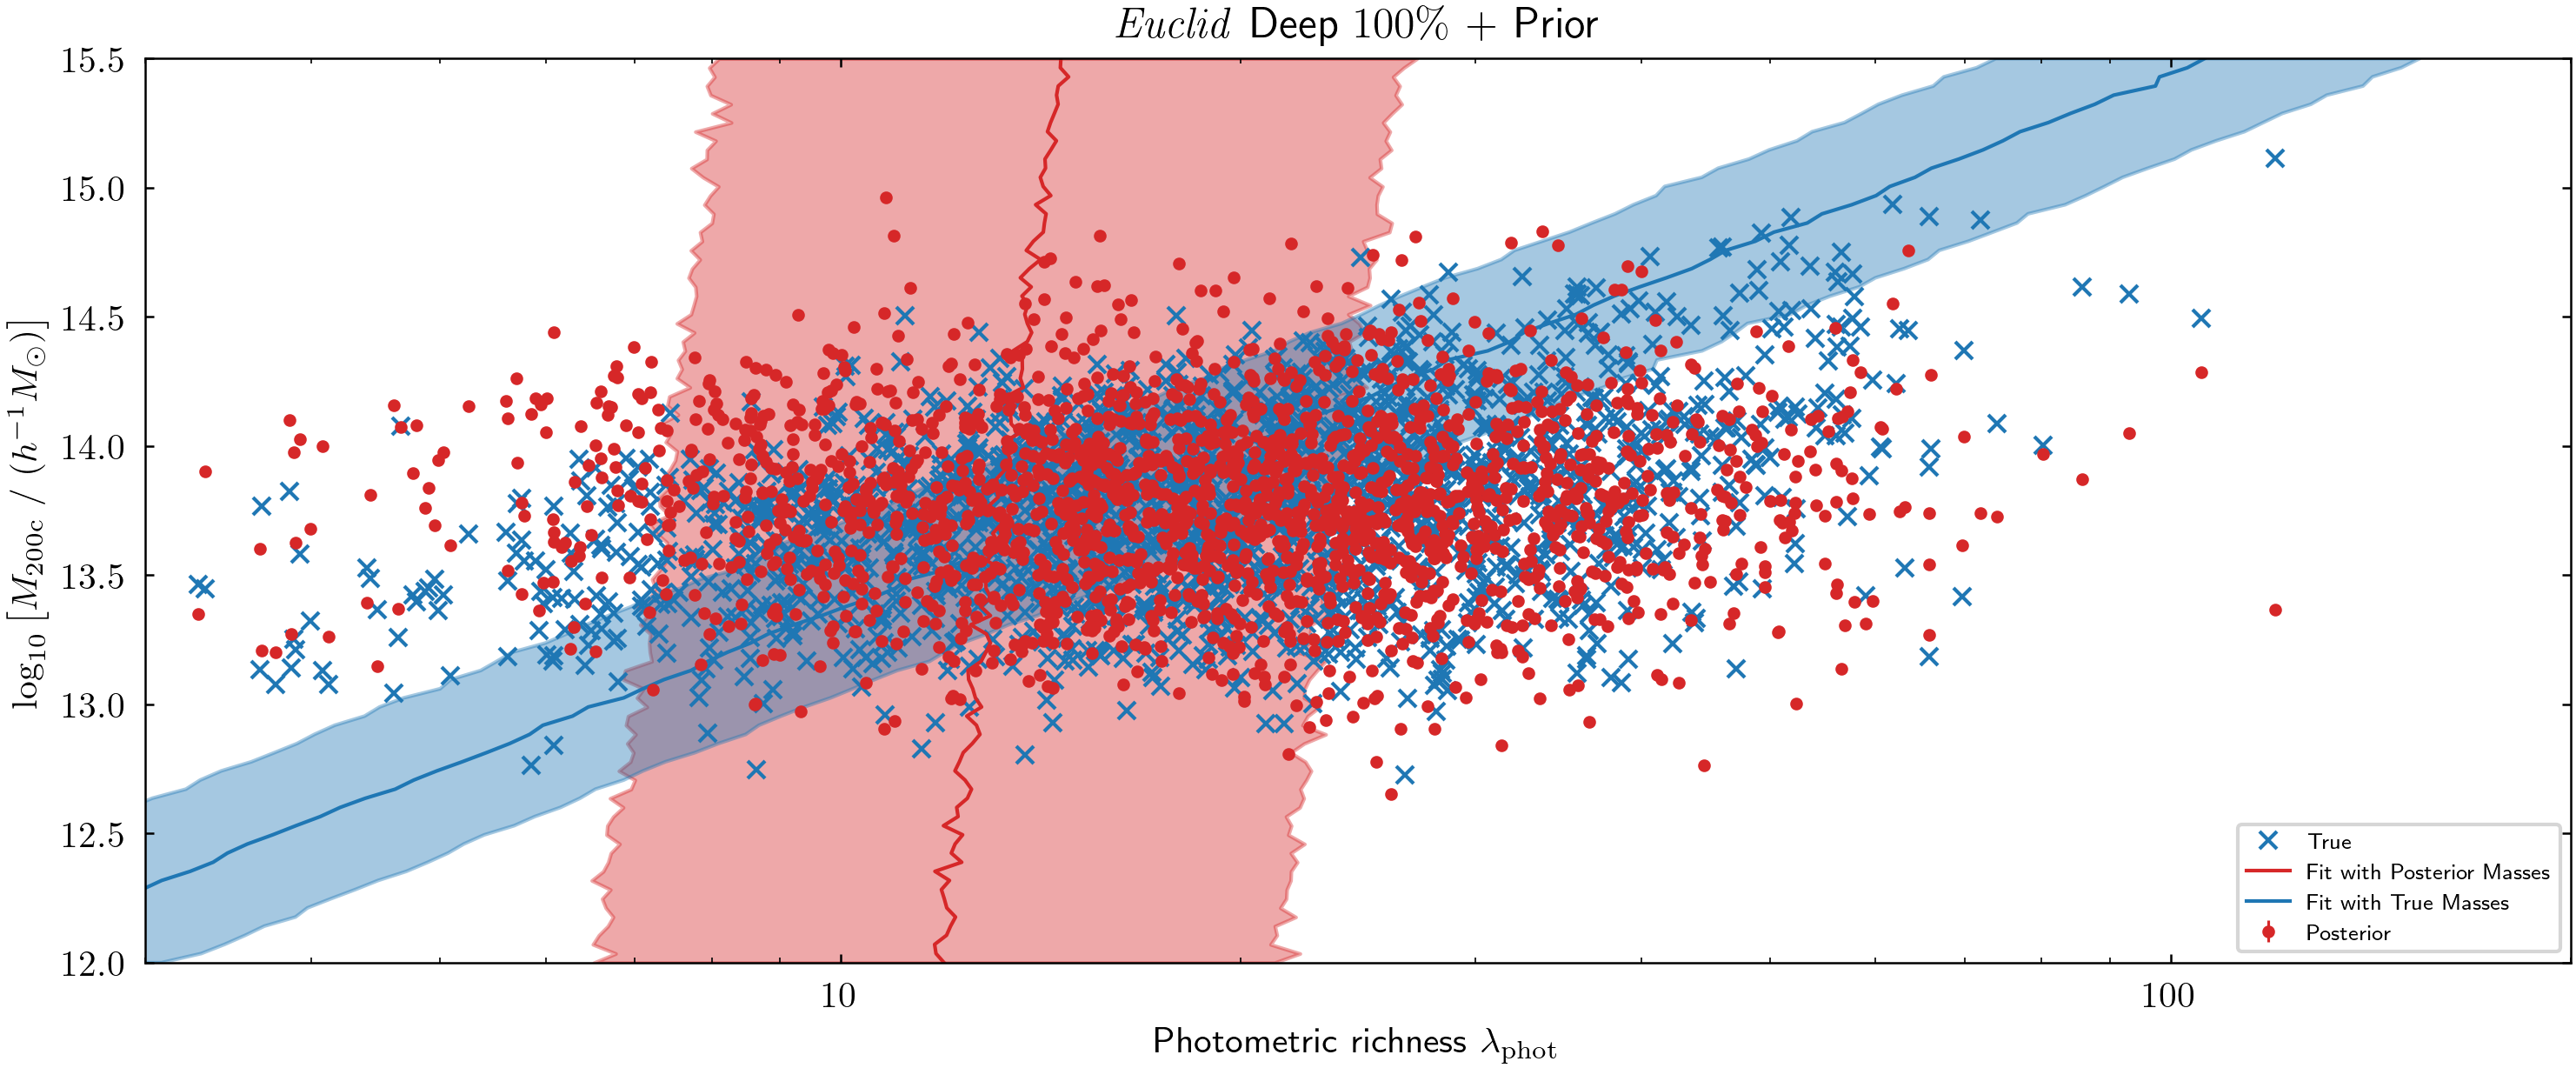

In [30]:
# Mass--richness fit: richness (x) vs M200c (y), as in v2
f, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.semilogx()

# posterior mass samples (median + 16/84) vs observed richness
p_ = np.percentile(samps, [16, 50, 84], axis=1)
ax.errorbar(rs, p_[1], yerr=[p_[1]-p_[0], p_[2]-p_[1]],
            fmt='.', label='Posterior', alpha=1, elinewidth=0.75, color='C3')

# true masses vs observed richness
ax.plot(rs, ytrue, 'x', label='True', alpha=1, markersize=5, color='C0')

# forward fit: evaluate predicted richness on a mass grid (the y-axis), then
# draw the richness scatter as a horizontal band via fill_betweenx
xm = np.linspace(12., 15.5, 100)   # mass grid (y-axis)
for s, color, lab in [(samples, 'C3', 'Fit with Posterior Masses'),
                      (truesamples, 'C0', 'Fit with True Masses')]:
    lines = lamb_mean(xm[:, None], z0, m0_piv, z0, s['pi0'], s['Fm'], s['Gz'])
    lines = lines + s['sigl']*np.random.randn(*lines.shape)
    # richness at each mass
    pr = np.percentile(10**lines, [16, 50, 84], axis=1)
    ax.plot(pr[1], xm, label=lab, c=color)
    ax.fill_betweenx(xm, pr[0], pr[2], alpha=0.4, color=color)

ax.set_xlim(3, 200)
ax.set_ylim(12., 15.5)
ax.set_xlabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_ylabel(r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')
ax.set_title(f'$\it{{Euclid}}$ {datatitles[d]} + {modeltitles[m]}')
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(loc='lower right', fontsize=6)

# f.savefig(f'figures/lambdam_fit_{d}.pdf', bbox_inches='tight')

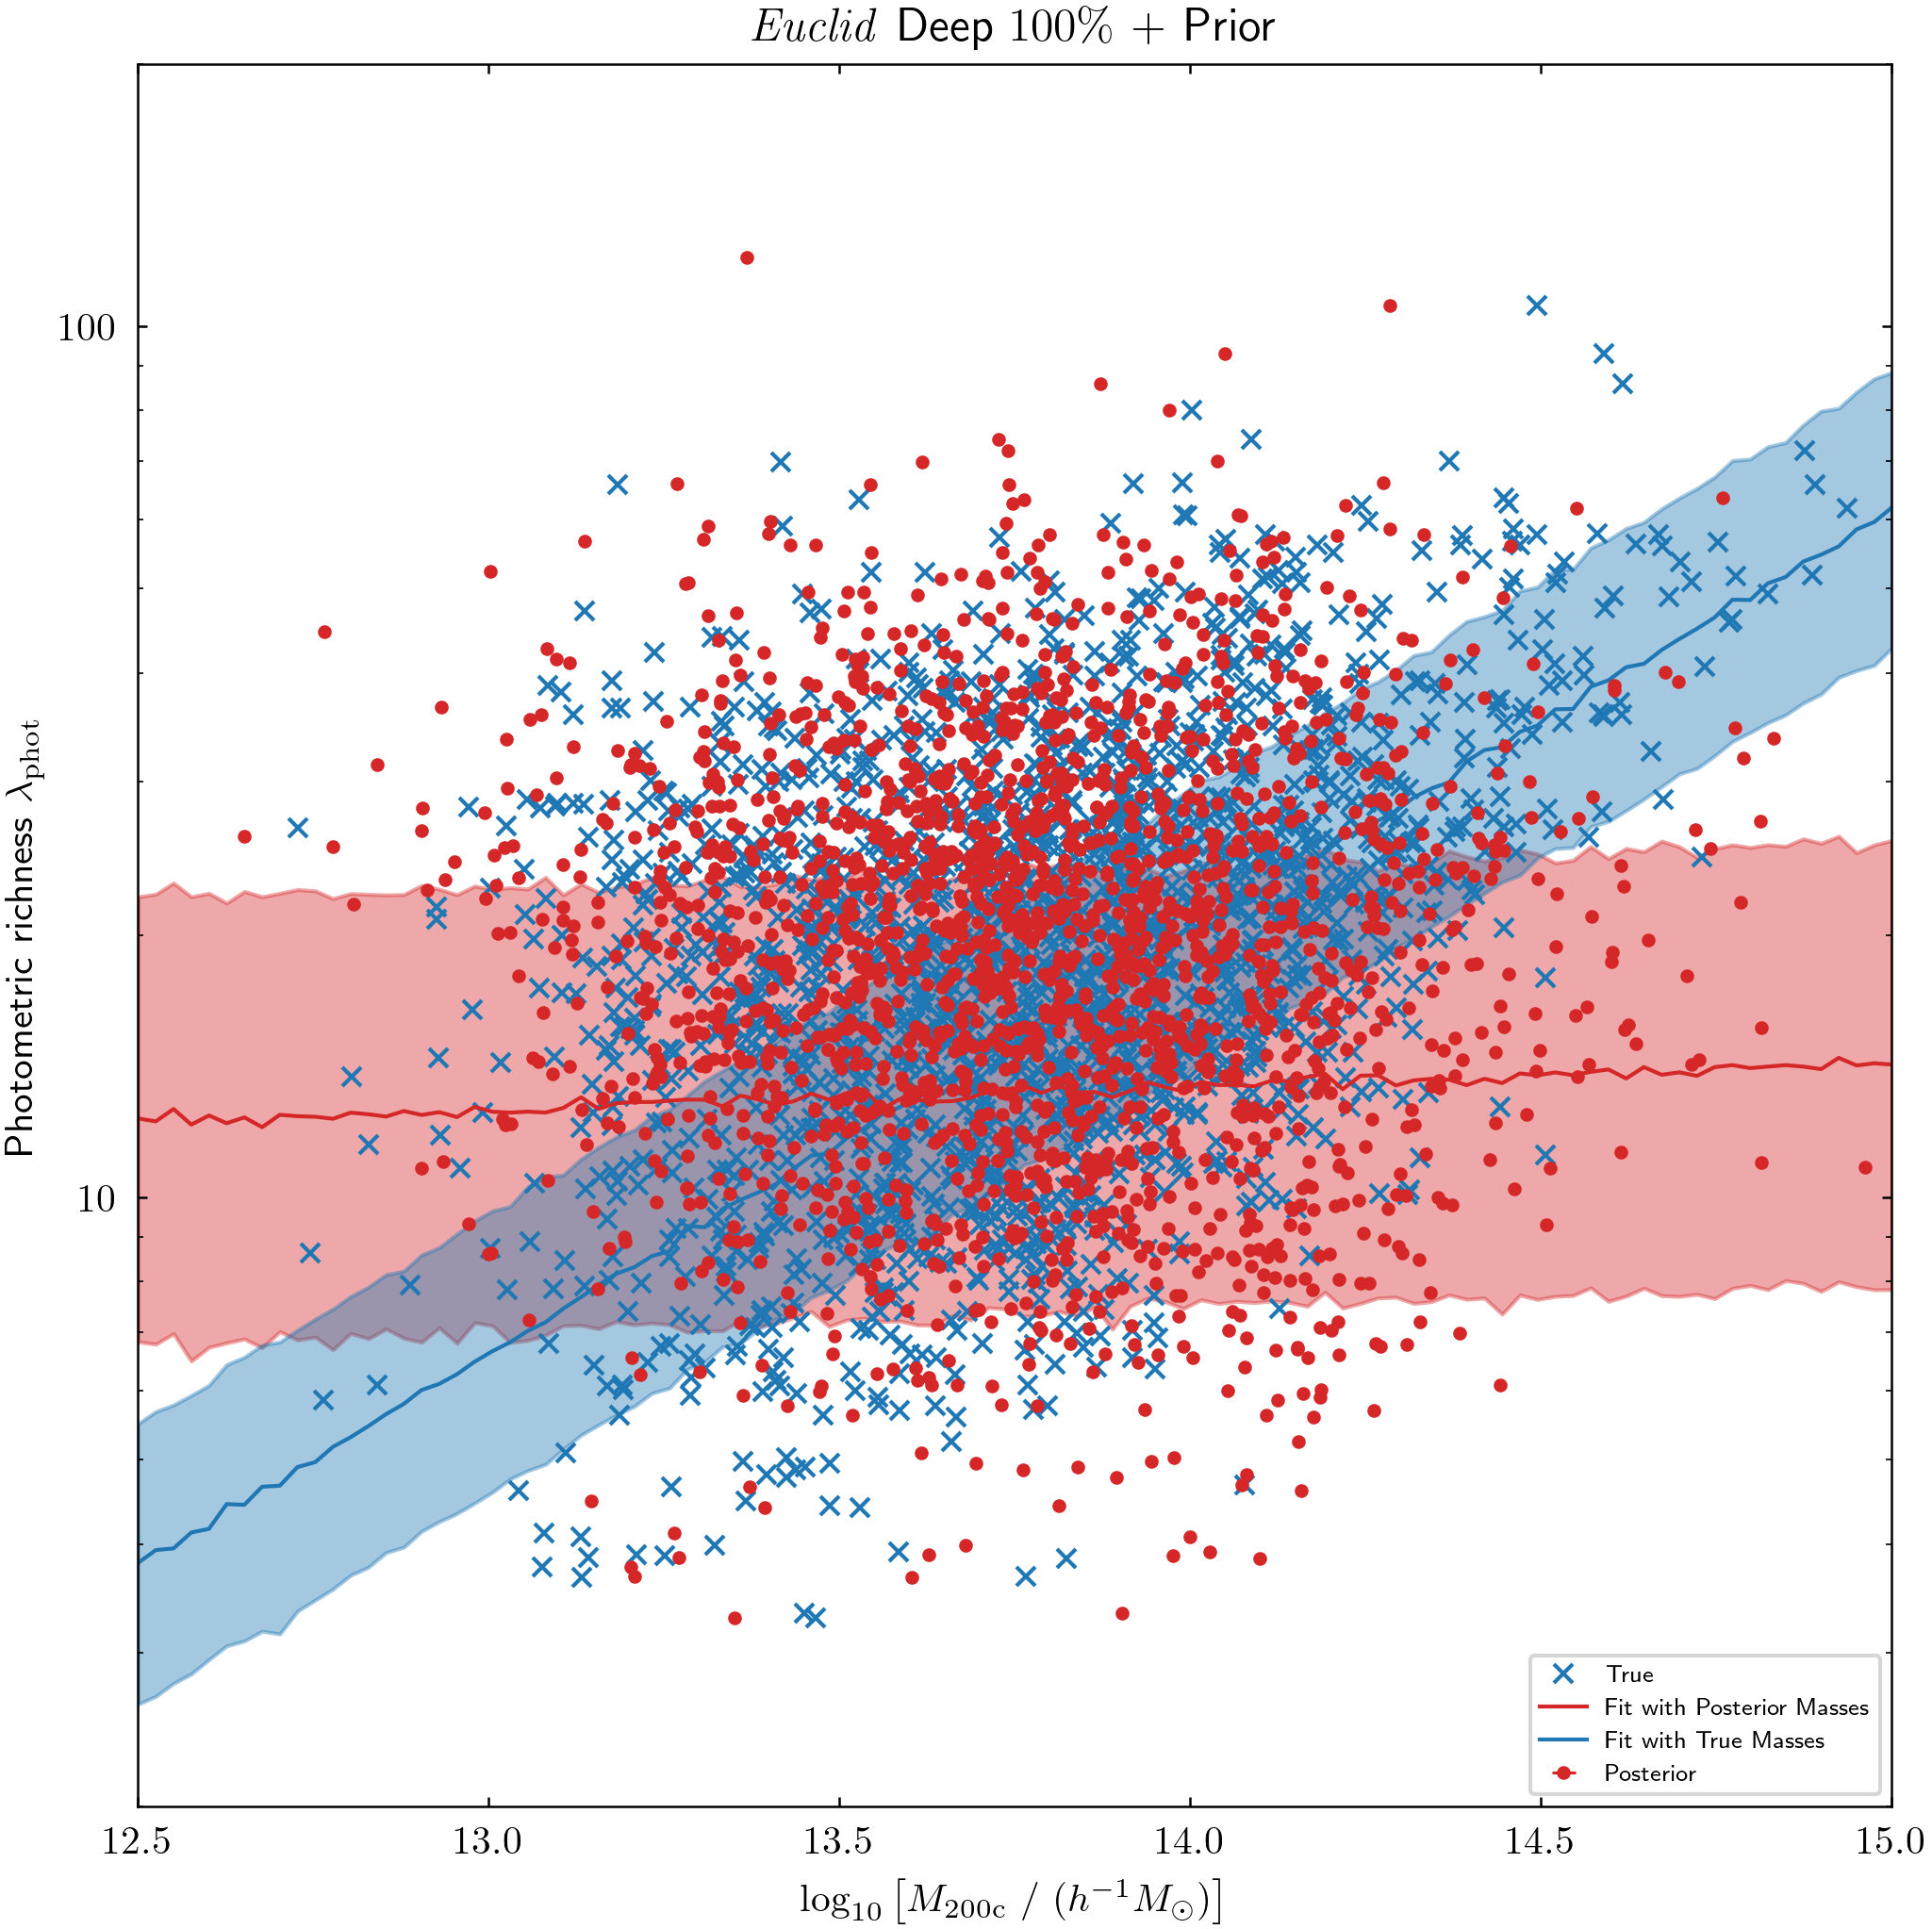

In [31]:
# Forward relation: predicted richness (y) as a function of mass (x)
f, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.semilogy()

# mass posteriors (x, median + 16/84) vs observed richness (y)
p_ = np.percentile(samps, [16, 50, 84], axis=1)
ax.errorbar(p_[1], rs, xerr=[p_[1]-p_[0], p_[2]-p_[1]],
            fmt='.', label='Posterior', alpha=1, elinewidth=0.75, color='C3')

# true masses (x) vs observed richness (y)
ax.plot(ytrue, rs, 'x', label='True', alpha=1, markersize=5, color='C0')

# fit grid in mass, evaluated at the redshift pivot
xm = np.linspace(12.5, 15.0, 100)

# fit with posterior masses, and with true masses (for reference)
for s, color, lab in [(samples, 'C3', 'Fit with Posterior Masses'),
                      (truesamples, 'C0', 'Fit with True Masses')]:
    lines = lamb_mean(xm[:, None], z0, m0_piv, z0, s['pi0'], s['Fm'], s['Gz'])
    lines = lines + s['sigl']*np.random.randn(*lines.shape)
    p_ = np.percentile(10**lines, [16, 50, 84], axis=1)
    ax.plot(xm, p_[1], label=lab, c=color)
    ax.fill_between(xm, p_[0], p_[2], alpha=0.4, color=color)

ax.set_xlim(12.5, 15.0)
ax.set_ylim(2, 200)
ax.set_xlabel(r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')
ax.set_ylabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_title(f'$\it{{Euclid}}$ {datatitles[d]} + {modeltitles[m]}')
ax.get_yaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(loc='lower right', fontsize=6)

# f.savefig(f'figures/lambdam_fit_{d}.pdf', bbox_inches='tight')

Mean ESS: 1.0 out of 100 samples
Minimum ESS: 1.0
Clusters with ESS < 10 (Danger Zone): 2014


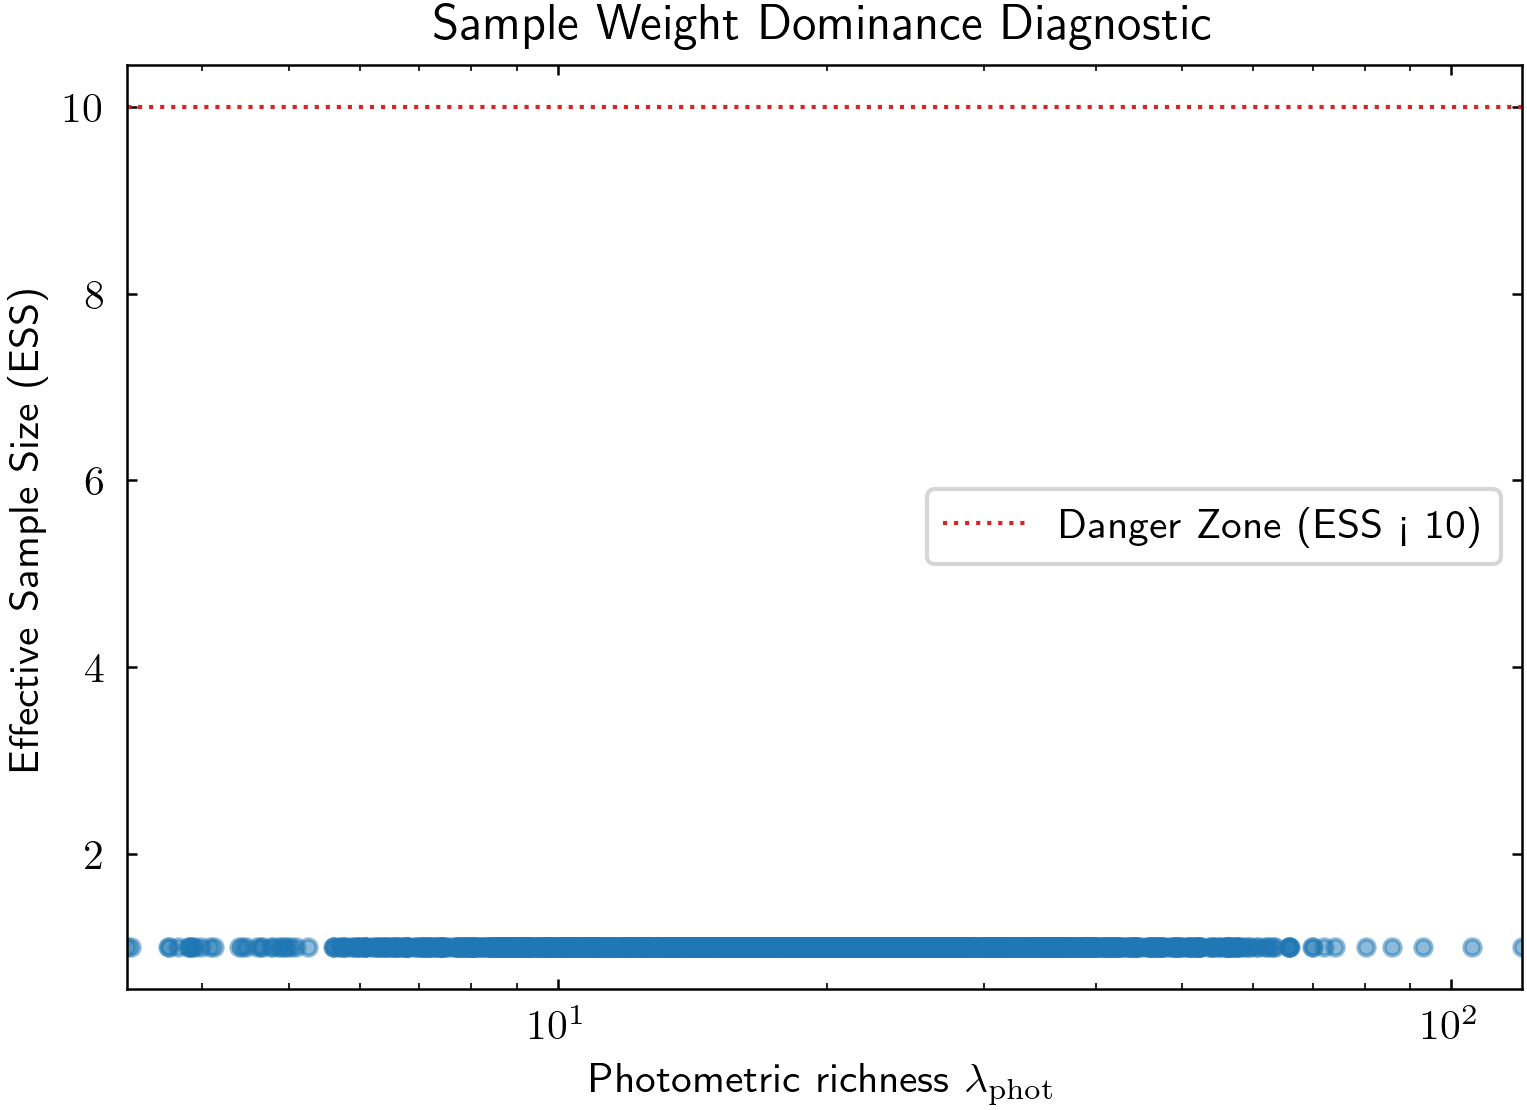

In [23]:
# Calculate median parameters from the existing MCMC samples
med_pi0 = np.median(samples['pi0'])
med_Fm = np.median(samples['Fm'])
med_Gz = np.median(samples['Gz'])
med_sigl = np.median(samples['sigl'])

# Evaluate the operand to get log-weights (fixed cut c0_fit, c1_fit)
log_weights = operand(samps, loglambs, zs, m0_piv, z0,
                      med_sigl, med_pi0, med_Fm, med_Gz, c0_fit, c1_fit)

# Convert to normalized weights safely to prevent overflow
log_w_max = np.max(log_weights, axis=1, keepdims=True)
w = np.exp(log_weights - log_w_max)
w_norm = w / np.sum(w, axis=1, keepdims=True)

# Calculate Effective Sample Size (ESS) for each cluster
ess = 1.0 / np.sum(w_norm**2, axis=1)

print(f"Mean ESS: {np.mean(ess):.1f} out of {Nsamp} samples")
print(f"Minimum ESS: {np.min(ess):.1f}")
print(f"Clusters with ESS < 10 (Danger Zone): {np.sum(ess < 10)}")

# Plot ESS vs Richness to identify where the fit is breaking
f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(rs, ess, alpha=0.5, s=15, color='C0')
ax.axhline(10, color='C3', linestyle=':', label='Danger Zone (ESS < 10)')
ax.set_xscale('log')
ax.set_xlabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_ylabel('Effective Sample Size (ESS)')
ax.set_title('Sample Weight Dominance Diagnostic')
ax.legend()
plt.show()

[Text(0.5, 0, 'Photometric richness $\\lambda_{\\rm phot}$'),
 Text(0, 0.5, '$\\log_{10}\\left[M_{\\rm 200c}\\ /\\ (h^{-1}M_{\\odot})\\right]$')]

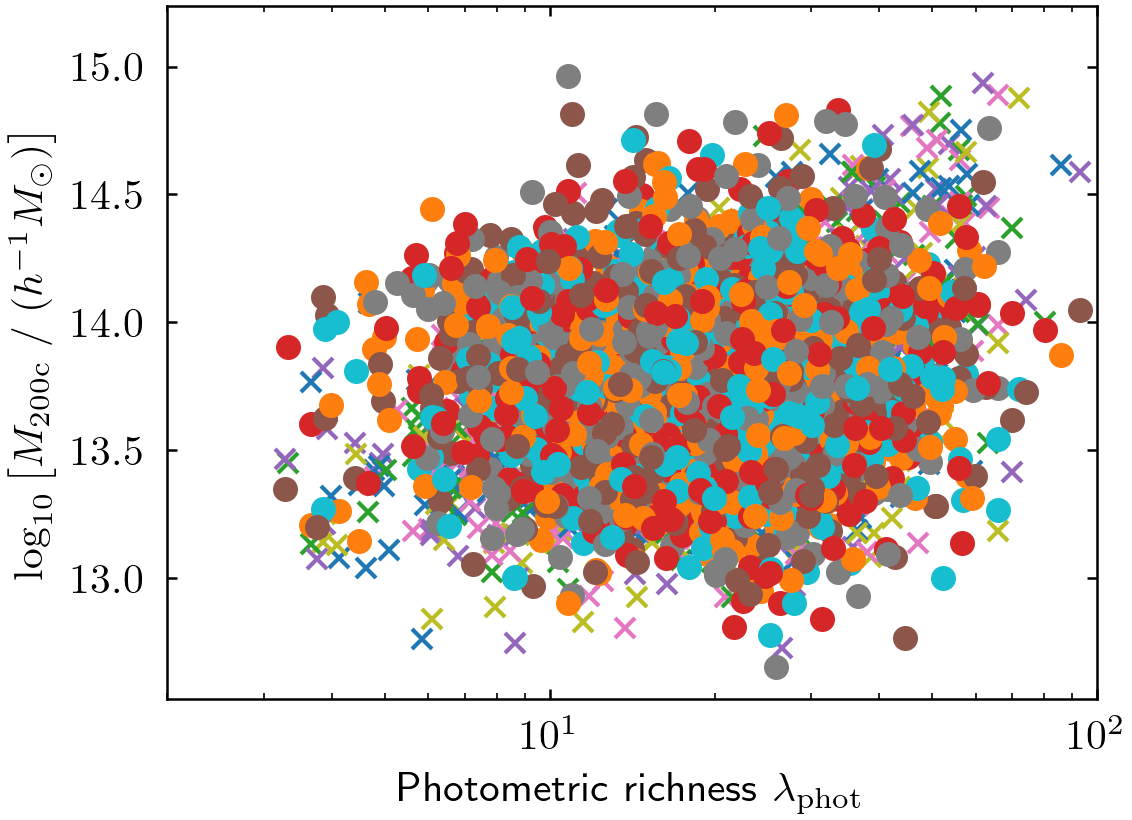

In [24]:
mask = ess < 10


f, ax = plt.subplots()
for i in np.argwhere(mask):
    ax.plot(rs[i], ytrue[i], 'x')
    ax.errorbar(rs[i], samps[i].mean(), yerr=samps[i].std(), fmt='o')

ax.semilogx()
ax.set_xlim(2, 100)
ax.set(xlabel=r'Photometric richness $\lambda_{\rm phot}$',
       ylabel=r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')